# ADHD-200 Site Generalization Pipeline

**Does a Brain-Scan ADHD Model Work on a Second Hospital's Data?**

This notebook combines the project's three working scripts into a single,
end-to-end pipeline:

| Step | Original script | What it does |
|---|---|---|
| 1 | `load_data.py` | Walks the ADHD-200 Athena CC200 time-course folders, computes a functional connectivity matrix per subject, and builds one feature table (one row per subject). |
| 2 | `merge_labels.py` | Loads the ADHD-200 training + testing phenotypic files, cleans subject IDs, and merges diagnosis (`DX`) and site labels onto the feature table. |
| 3 | `run_models.py` | Answers **RQ1**: how large is the accuracy/AUC/F1 gap between mixed-site k-fold evaluation and leave-one-site-out (LOSO) evaluation? |

Each step below is unchanged in logic from the original script — only the
file-path handling was consolidated into one configuration cell so the whole
pipeline can run top-to-bottom in one notebook, with intermediate CSVs still
written to `outputs/` (so you can inspect or hand off files exactly as the
original scripts did, and so this notebook doubles as your "proof of active
work" artifact for the presentation).

**Run order matters:** Step 1 must run before Step 2, and Step 2 must run
before Step 3, since each step's output feeds the next.


## 0. Configuration

Adjust `PROJECT_ROOT` if this notebook does not sit in the same folder the
original scripts expected (one level above `data/` and `outputs/`). Everything
else derives from it, so you only need to change this one line.

Expected folder layout under `PROJECT_ROOT`:

```
PROJECT_ROOT/
  data/
    ADHD200_CC200_TCs_filtfix/
      KKI/<subject_id>/sfnwmrda..._cc200_TCs.1D
      NYU/...
      ...
    ADHD200_training_pheno/
      <site>/*phenotypic*
    ADHD200_testing_pheno/
      <site>/*phenotypic*
  outputs/            <- created automatically if missing
```


In [1]:
import os

# ---- CONFIG: the one thing you may need to change ----
PROJECT_ROOT = "/Users/abenezerghiday/Documents/ML_Project_ADHD"  # absolute path to your project folder

DATA_ROOT = os.path.join(PROJECT_ROOT, "ADHD200_CC200_TCs_filtfix")
TRAIN_PHENO_ROOT = os.path.join(PROJECT_ROOT, "ADHD200_training_pheno")
TEST_PHENO_ROOT = os.path.join(PROJECT_ROOT, "ADHD200_testing_pheno")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

FEATURES_PATH = os.path.join(OUTPUT_DIR, "features.csv")
FEATURES_WITH_LABELS_PATH = os.path.join(OUTPUT_DIR, "features_with_labels.csv")
MIXED_RESULTS_PATH = os.path.join(OUTPUT_DIR, "mixed_kfold_results.csv")
LOSO_RESULTS_PATH = os.path.join(OUTPUT_DIR, "loso_results.csv")

N_ROIS = 200  # CC200 atlas has up to 200 regions (some may be missing per subject)
N_PCA_COMPONENTS = 100
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Data root:   ", os.path.abspath(DATA_ROOT))
print("Output dir:  ", os.path.abspath(OUTPUT_DIR))


Data root:    /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_CC200_TCs_filtfix
Output dir:   /Users/abenezerghiday/Documents/ML_Project_ADHD/outputs


## 1. Load Time Courses & Build Connectivity Features

*(from `load_data.py`)*

Walks through the ADHD-200 Athena CC200 time-course folders, computes a
functional connectivity matrix per subject, and saves one big feature table
(one row per subject) to `outputs/features.csv`.

**Folder structure expected:**

```
data/
  ADHD200_CC200_TCs_filtfix/
    KKI/
      1996183/
        sfnwmrda1996183_session_1_rest_1_cc200_TCs.1D
        snwmrda1996183_session_1_rest_1_cc200_TCs.1D
      2014113/
        ...
    NYU/
      ...
    ...
```


In [2]:
import numpy as np
import pandas as pd


def find_timecourse_file(subject_folder):
    """Find the 'sfnwmrda...' file (filtered version) inside a subject folder."""
    for fname in os.listdir(subject_folder):
        if fname.startswith("sfnwmrda") and fname.endswith(".1D"):
            return os.path.join(subject_folder, fname)
    return None


def load_timecourse(filepath):
    """
    Load a CC200 time-course .1D file into a DataFrame of shape
    (n_timepoints, n_rois_present), reindexed to always have
    columns Mean_1 ... Mean_200 (missing ROIs filled with NaN).
    """
    df = pd.read_csv(filepath, sep=r"\s+")

    # The first two columns are 'File' and 'Sub-brick' (metadata, not signal)
    meta_cols = [c for c in df.columns if c.lower() in ("file", "sub-brick")]
    roi_cols = [c for c in df.columns if c not in meta_cols]

    df = df[roi_cols]

    # Rename columns to a consistent Mean_1..Mean_200 scheme, filling gaps with NaN
    full_cols = [f"Mean_{i}" for i in range(1, N_ROIS + 1)]
    df = df.reindex(columns=full_cols)  # missing ROI columns become all-NaN

    # Convert everything to numeric (in case of stray text)
    df = df.apply(pd.to_numeric, errors="coerce")

    return df


def compute_connectivity_features(timecourse_df):
    """
    Compute the upper-triangle of the ROI-by-ROI correlation matrix
    and flatten it into a 1D feature vector.
    """
    corr = timecourse_df.corr()  # NaN-safe pairwise correlation
    # Upper triangle, excluding the diagonal
    iu = np.triu_indices(corr.shape[0], k=1)
    features = corr.values[iu]
    return features


In [3]:
NON_SITE_FOLDERS = {"templates"}  # not a real site -- the CC200 atlas file ships alongside the data


def build_feature_table(data_root=DATA_ROOT):
    rows = []
    site_folders = [
        f for f in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, f)) and f not in NON_SITE_FOLDERS
    ]

    print(f"Found {len(site_folders)} site folders: {site_folders}")

    for site in site_folders:
        site_path = os.path.join(data_root, site)
        subject_folders = [
            f for f in os.listdir(site_path)
            if os.path.isdir(os.path.join(site_path, f))
        ]

        print(f"  Site '{site}': {len(subject_folders)} subject folders")

        for subject_id in subject_folders:
            subject_path = os.path.join(site_path, subject_id)
            tc_file = find_timecourse_file(subject_path)

            if tc_file is None:
                print(f"    [SKIP] No sfnwmrda .1D file found for subject {subject_id} in {site}")
                continue

            try:
                tc_df = load_timecourse(tc_file)
                features = compute_connectivity_features(tc_df)
            except Exception as e:
                print(f"    [ERROR] Failed on subject {subject_id} in {site}: {e}")
                continue

            row = {"subject_id": subject_id, "site": site}
            for i, val in enumerate(features):
                row[f"conn_{i}"] = val
            rows.append(row)

    print(f"\nLoaded {len(rows)} subjects total.")
    return pd.DataFrame(rows)


feature_df = build_feature_table()
feature_df.to_csv(FEATURES_PATH, index=False)
print(f"Saved feature table to {FEATURES_PATH}")
print(f"Shape: {feature_df.shape}")
feature_df.head()


Found 9 site folders: ['WashU', 'Peking_3', 'Peking_2', 'NYU', 'NeuroIMAGE', 'OHSU', 'KKI', 'Peking_1', 'Pittsburgh']
  Site 'WashU': 61 subject folders
    [SKIP] No sfnwmrda .1D file found for subject 0015011 in WashU
    [SKIP] No sfnwmrda .1D file found for subject 0015018 in WashU
  Site 'Peking_3': 42 subject folders
  Site 'Peking_2': 67 subject folders
  Site 'NYU': 222 subject folders
    [SKIP] No sfnwmrda .1D file found for subject 0010016 in NYU
    [SKIP] No sfnwmrda .1D file found for subject 0010027 in NYU
    [SKIP] No sfnwmrda .1D file found for subject 0010105 in NYU
    [SKIP] No sfnwmrda .1D file found for subject 0010127 in NYU
    [SKIP] No sfnwmrda .1D file found for subject 0010098 in NYU
    [SKIP] No sfnwmrda .1D file found for subject 0010055 in NYU
  Site 'NeuroIMAGE': 48 subject folders
  Site 'OHSU': 79 subject folders
  Site 'KKI': 83 subject folders
  Site 'Peking_1': 85 subject folders
  Site 'Pittsburgh': 89 subject folders

Loaded 768 subjects total.


,subject_id,site,conn_0,conn_1,conn_2,conn_3,conn_4,conn_5,conn_6,conn_7,...,conn_19890,conn_19891,conn_19892,conn_19893,conn_19894,conn_19895,conn_19896,conn_19897,conn_19898,conn_19899
0,0015042,WashU,NaN,-0.331521,-0.470982,NaN,-0.158182,-0.008185,0.058724,0.304973,...,0.329025,0.228614,-0.395894,-0.396858,0.494769,0.249310,-0.176926,0.473072,-0.244243,0.117380
1,0015045,WashU,NaN,0.256376,-0.077275,NaN,-0.033564,0.235934,0.207506,-0.087227,...,0.296602,0.442802,-0.034949,-0.243630,0.219415,0.080636,0.064977,0.527581,-0.633795,-0.489882
2,0015016,WashU,NaN,-0.152798,-0.153711,NaN,-0.137472,0.143257,0.252641,0.576102,...,0.079436,0.540266,0.459473,-0.251695,-0.151090,-0.178859,-0.206457,0.596615,-0.242581,0.081780
3,0015029,WashU,NaN,-0.047604,-0.387096,NaN,0.280945,-0.211757,-0.034377,0.413740,...,0.193432,-0.134150,-0.473512,-0.310972,-0.123604,-0.373026,0.272646,0.430615,0.018039,0.404654
4,0015020,WashU,NaN,-0.731004,-0.091991,NaN,-0.558210,0.436229,0.509190,0.510461,...,-0.131274,-0.255393,-0.655239,-0.011704,0.003697,0.123437,-0.107233,0.567185,-0.523122,-0.154904


In [4]:
# Quick preview: shape + first few columns (full table is ~19,900 columns wide,
# so a plain .head() is unreadable -- this narrows it down)
print(f"Shape: {feature_df.shape[0]} subjects x {feature_df.shape[1]} columns")
feature_df.iloc[:5, :6]


Shape: 768 subjects x 19902 columns


,subject_id,site,conn_0,conn_1,conn_2,conn_3
0,0015042,WashU,NaN,-0.331521,-0.470982,NaN
1,0015045,WashU,NaN,0.256376,-0.077275,NaN
2,0015016,WashU,NaN,-0.152798,-0.153711,NaN
3,0015029,WashU,NaN,-0.047604,-0.387096,NaN
4,0015020,WashU,NaN,-0.731004,-0.091991,NaN


### 1a. Handle Structurally Missing CC200 Regions

Some CC200 atlas regions fall outside the scan field of view for every subject
in this dataset -- when that happens, EVERY correlation involving that region
is `NaN` for 100% of subjects, not just a few. There is no mean to impute for
a column with zero real values, so these must be dropped outright (rather than
handed to `SimpleImputer`, which would leave them as `NaN` and crash the
scaler/PCA step downstream in Section 3).

This is a documented property of the CC200 parcellation on ADHD-200 --
several published papers report using ~190 effective regions instead of the
nominal 200 for exactly this reason. Columns that are only *partially*
missing (some subjects, not all) are left in place; `SimpleImputer` in
Section 3 handles those safely by filling with the column mean.


In [5]:
conn_cols = [c for c in feature_df.columns if c.startswith("conn_")]
missing_frac = feature_df[conn_cols].isna().mean()

fully_missing_cols = missing_frac[missing_frac == 1.0].index.tolist()
partially_missing_cols = missing_frac[(missing_frac > 0) & (missing_frac < 1.0)].index.tolist()

print(f"Total connectivity columns before cleanup: {len(conn_cols)}")
print(f"Dropping {len(fully_missing_cols)} columns that are 100% missing (structurally absent ROI pairs)")
print(f"Keeping {len(partially_missing_cols)} columns with partial missingness "
      f"(will be mean-imputed in Section 3)")

feature_df = feature_df.drop(columns=fully_missing_cols)
print(f"\nNew shape after dropping fully-missing columns: {feature_df.shape}")

# Re-save so Section 2 (merge) and Section 3 (modeling) both use the cleaned table
feature_df.to_csv(FEATURES_PATH, index=False)
print(f"Re-saved cleaned feature table to {FEATURES_PATH}")


Total connectivity columns before cleanup: 19900
Dropping 1945 columns that are 100% missing (structurally absent ROI pairs)
Keeping 1484 columns with partial missingness (will be mean-imputed in Section 3)

New shape after dropping fully-missing columns: (768, 17957)
Re-saved cleaned feature table to /Users/abenezerghiday/Documents/ML_Project_ADHD/outputs/features.csv


## 2. Merge Phenotypic Labels

*(from `merge_labels.py`)*

Loads every phenotypic file under the training phenotypic root, standardizes
each site's subject-ID column to one consistent name (some sites, like
WashU, spell it slightly differently), normalizes subject IDs (handling
leading zeros, floats like `1018959.0`, and plain ints), and left-merges
diagnosis (`DX`) and demographic columns onto the feature table built in
Step 1.


In [6]:
import glob

PHENO_ROOTS = [TRAIN_PHENO_ROOT]  # training release ONLY -- the testing release has every DX-related
                                   # field set to "withheld" and must never be merged in as labels

ID_COLUMN_CANDIDATES = ["ScanDir ID", "ScanDirID", "Subject", "subject_id"]


def find_phenotypic_file(site_folder):
    """Find any file with 'phenotypic' in its name inside a site folder."""
    candidates = glob.glob(os.path.join(site_folder, "*phenotypic*"))
    return candidates[0] if candidates else None


def load_one_phenotypic_file(filepath):
    """
    Try loading as comma-separated first, then tab-separated,
    since these files may or may not show a real .csv/.tsv extension.
    """
    try:
        df = pd.read_csv(filepath)
        if df.shape[1] > 1:
            return df
    except Exception:
        pass

    # Fallback: try tab-separated
    df = pd.read_csv(filepath, sep="\t")
    return df


def standardize_id_column(df, id_col_candidates=ID_COLUMN_CANDIDATES):
    """
    Different ADHD-200 sites spell the subject-ID column differently --
    e.g. WashU's file uses "ScanDirID" (no space) while every other site
    uses "ScanDir ID" (with a space). If we wait until AFTER every site's
    file is concatenated together to pick one column name, whichever name
    was used by the minority of sites ends up blank for every row from a
    site that used a different spelling -- silently, with no error.

    This renames whichever candidate is present in THIS ONE FILE to a
    single canonical name, before it ever gets concatenated with anything
    else, so every site's IDs survive regardless of the original file's
    exact column name.
    """
    for cand in id_col_candidates:
        if cand in df.columns:
            if cand != "ScanDir ID":
                df = df.rename(columns={cand: "ScanDir ID"})
            return df
    raise KeyError(
        f"Could not find a subject ID column. Looked for: {id_col_candidates}. "
        f"Actual columns: {list(df.columns)}"
    )


def gather_all_phenotypic_data(pheno_roots=PHENO_ROOTS):
    all_rows = []

    for pheno_root in pheno_roots:
        if not os.path.isdir(pheno_root):
            print(f"[WARN] Phenotypic root not found: {pheno_root}")
            continue

        site_folders = [
            f for f in os.listdir(pheno_root)
            if os.path.isdir(os.path.join(pheno_root, f))
        ]

        for site in site_folders:
            site_path = os.path.join(pheno_root, site)
            pheno_file = find_phenotypic_file(site_path)

            if pheno_file is None:
                print(f"  [SKIP] No phenotypic file found in {site_path}")
                continue

            try:
                df = load_one_phenotypic_file(pheno_file)
                df = standardize_id_column(df)
            except Exception as e:
                print(f"  [ERROR] Failed to load {pheno_file}: {e}")
                continue

            df["source_pheno_site_folder"] = site  # for debugging/traceability
            all_rows.append(df)
            print(f"  Loaded {len(df)} rows from {pheno_file}")

    if not all_rows:
        raise RuntimeError("No phenotypic files were loaded at all. Check PHENO_ROOTS paths.")

    combined = pd.concat(all_rows, ignore_index=True)
    return combined


def clean_id_series(id_series):
    """
    Robustly normalize a subject-ID column to a plain integer-like string,
    regardless of whether the source had leading zeros ('0010016'),
    was read back as a float ('1018959.0'), or as a plain int (1018959).
    """
    numeric = pd.to_numeric(id_series, errors="coerce")  # handles '1018959.0', '0010016', 1018959, etc.
    # Int64 is pandas' *nullable* integer type, so NaNs survive without crashing
    return numeric.astype("Int64").astype(str)


def normalize_id_column(df, id_col_candidates):
    """Find the subject ID column and normalize it to a clean, comparable string."""
    id_col = None
    for cand in id_col_candidates:
        if cand in df.columns:
            id_col = cand
            break

    if id_col is None:
        raise KeyError(
            f"Could not find a subject ID column. Looked for: {id_col_candidates}. "
            f"Actual columns: {list(df.columns)}"
        )

    df["subject_id_clean"] = clean_id_series(df[id_col])
    return df


In [7]:
print("Gathering phenotypic files...")
pheno_df = gather_all_phenotypic_data()
print(f"\nTotal phenotypic rows before dedup: {len(pheno_df)}")

# The ID column is called 'ScanDir ID' based on what we saw in KKI_phenotypic
pheno_df = normalize_id_column(pheno_df, id_col_candidates=["ScanDir ID", "ScanDirID", "Subject", "subject_id"])

# Some subjects may appear in both train/test exports; keep first occurrence
pheno_df = pheno_df.drop_duplicates(subset="subject_id_clean", keep="first")
print(f"Total phenotypic rows after dedup: {len(pheno_df)}")

print("\nLoading connectivity features...")
features_df = pd.read_csv(FEATURES_PATH)
print(f"Features table shape: {features_df.shape}")

features_df["subject_id_clean"] = clean_id_series(features_df["subject_id"])

# --- DEBUG: show sample IDs from both sides so we can visually confirm they line up ---
print("\nSample feature-table IDs:", features_df["subject_id_clean"].head(5).tolist())
print("Sample phenotypic IDs:   ", pheno_df["subject_id_clean"].head(5).tolist())
overlap_count = features_df["subject_id_clean"].isin(pheno_df["subject_id_clean"]).sum()
print(f"Feature IDs that DO appear somewhere in phenotypic IDs: {overlap_count} / {len(features_df)}")

print("\nMerging...")
merged = features_df.merge(
    pheno_df,
    on="subject_id_clean",
    how="left",
    suffixes=("", "_pheno"),
)

n_missing_dx = merged["DX"].isna().sum() if "DX" in merged.columns else "N/A (no DX column found)"
print(f"Subjects with NO matching phenotypic row (missing DX): {n_missing_dx}")

merged.to_csv(FEATURES_WITH_LABELS_PATH, index=False)
print(f"\nSaved merged table to {FEATURES_WITH_LABELS_PATH}")
print(f"Final shape: {merged.shape}")
merged.head()


Gathering phenotypic files...
  Loaded 61 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/WashU/WashU_phenotypic.csv
  Loaded 42 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/Peking_3/Peking_3_phenotypic.csv
  Loaded 67 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/Peking_2/Peking_2_phenotypic.csv
  Loaded 222 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/NYU/NYU_phenotypic.csv
  Loaded 48 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/NeuroIMAGE/NeuroIMAGE_phenotypic.csv
  Loaded 79 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/OHSU/OHSU_phenotypic.csv
  Loaded 83 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/KKI/KKI_phenotypic.csv
  Loaded 85 rows from /Users/abenezerghiday/Documents/ML_Project_ADHD/ADHD200_training_pheno/Peking_1/Peking_1_phenot

/var/folders/6s/46zbqlqx38qf_n3wv9lvvtlh0000gn/T/ipykernel_62925/573974019.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features_df["subject_id_clean"] = clean_id_series(features_df["subject_id"])



Saved merged table to /Users/abenezerghiday/Documents/ML_Project_ADHD/outputs/features_with_labels.csv
Final shape: (768, 17993)


,subject_id,site,conn_1,conn_2,conn_4,conn_5,conn_6,conn_7,conn_8,conn_10,...,QC_S2_Rest_1,QC_S2_Rest_2,QC_S2_Anat,source_pheno_site_folder,QC_Rest_1,QC_Rest_2,QC_Rest_3,QC_Rest_4,QC_Anatomical_1,QC_Anatomical_2
0,15042,WashU,-0.331521,-0.470982,-0.158182,-0.008185,0.058724,0.304973,0.026510,-0.159564,...,NaN,NaN,NaN,WashU,NaN,NaN,NaN,NaN,NaN,NaN
1,15045,WashU,0.256376,-0.077275,-0.033564,0.235934,0.207506,-0.087227,-0.041848,-0.051763,...,NaN,NaN,NaN,WashU,NaN,NaN,NaN,NaN,NaN,NaN
2,15016,WashU,-0.152798,-0.153711,-0.137472,0.143257,0.252641,0.576102,0.167686,-0.000523,...,0.0,NaN,1.0,WashU,NaN,NaN,NaN,NaN,NaN,NaN
3,15029,WashU,-0.047604,-0.387096,0.280945,-0.211757,-0.034377,0.413740,-0.053230,0.273358,...,NaN,NaN,NaN,WashU,NaN,NaN,NaN,NaN,NaN,NaN
4,15020,WashU,-0.731004,-0.091991,-0.558210,0.436229,0.509190,0.510461,-0.333189,-0.670752,...,0.0,0.0,NaN,WashU,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Quick preview: shape + just the columns that matter most for a sanity check
# (the merged table also has ~19,900 connectivity columns -- skip straight to labels)
print(f"Shape: {merged.shape[0]} subjects x {merged.shape[1]} columns")
preview_cols = [c for c in ["subject_id", "site", "DX", "Age", "Gender"] if c in merged.columns]
merged[preview_cols].head(10)


Shape: 768 subjects x 17993 columns


,subject_id,site,DX,Age,Gender
0,15042,WashU,0,13.66,1.0
1,15045,WashU,0,13.18,1.0
2,15016,WashU,0,8.30,1.0
3,15029,WashU,0,11.24,1.0
4,15020,WashU,0,8.41,0.0
5,15027,WashU,0,14.89,0.0
6,15044,WashU,0,10.35,1.0
7,15043,WashU,0,14.56,1.0
8,15026,WashU,0,10.11,0.0
9,15019,WashU,0,8.28,1.0


## 2a. Initial Data Exploration

Before moving to modeling, two quick checks on the merged dataset:

- **Class distribution** — how many Control vs. ADHD subjects we actually have, since an imbalanced dataset (like our 488/280 split) affects how metrics like accuracy should be interpreted.
- **Subjects per site** — confirms every site made it through the merge with a reasonable sample size, and previews which sites (e.g. NYU, with 216 subjects) will carry more weight in the mixed k-fold split, or which small sites (e.g. Peking_3, 42 subjects) will make for a thin LOSO test fold.

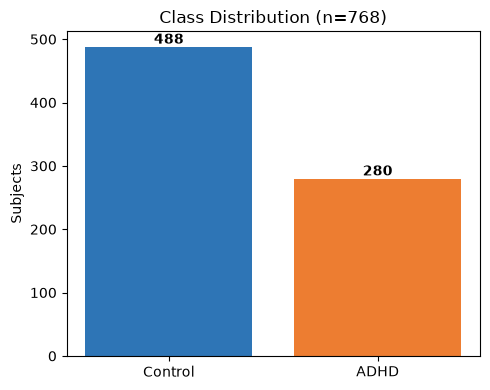

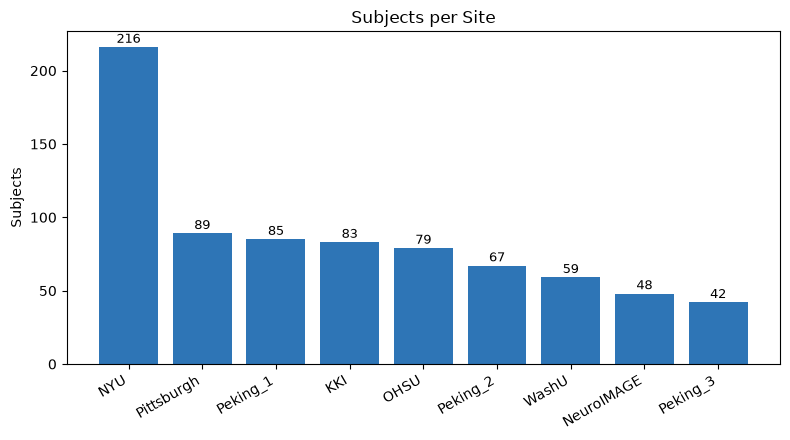

Total: 768 subjects across 9 sites
Class balance: {'Control': 488, 'ADHD': 280}


In [16]:
import matplotlib.pyplot as plt
class_counts = (merged["DX"] != 0).map({False: "Control", True: "ADHD"}).value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_counts.index, class_counts.values, color=["#2E75B6", "#ED7D31"])
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontweight="bold")
ax.set_ylabel("Subjects")
ax.set_title(f"Class Distribution (n={len(merged)})")
plt.tight_layout()
plt.show()

# --- Chart 2: Subjects per site ---
site_counts = merged["site"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(site_counts.index, site_counts.values, color="#2E75B6")
for i, v in enumerate(site_counts.values):
    ax.text(i, v + 3, str(v), ha="center", fontsize=9)
ax.set_ylabel("Subjects")
ax.set_title("Subjects per Site")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Total: {len(merged)} subjects across {merged['site'].nunique()} sites")
print(f"Class balance: {class_counts.to_dict()}")

## 3. Baseline Models: Mixed-Site k-Fold vs. Leave-One-Site-Out (LOSO)

*(from `run_models.py`)*

**RQ1: How large is the accuracy/AUC/F1 gap between mixed-site k-fold
evaluation and leave-one-site-out (LOSO) evaluation on ADHD-200?**

This step:
1. Loads `features_with_labels.csv` (from Step 2)
2. Drops subjects with no diagnosis label
3. Binarizes `DX`: 0 = control, anything else = ADHD
4. Runs mixed-site 5-fold stratified cross-validation
5. Runs Leave-One-Site-Out (LOSO) cross-validation
6. Prints accuracy / AUC / F1 for both, so you can see the gap

The model pipeline (Impute → Scale → PCA → Logistic Regression) is refit from
scratch inside every single fold, so no information about the held-out
subjects/site ever leaks into training.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score


def build_pipeline():
    """A fresh, unfitted pipeline. Called separately for every fold so
    nothing learned from test data ever touches training."""
    return Pipeline([
        ("impute", SimpleImputer(strategy="mean")),
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


def evaluate_predictions(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_proba) if len(set(y_true)) > 1 else float("nan"),
        "f1": f1_score(y_true, y_pred),
    }


def run_mixed_kfold(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        pipe = build_pipeline()
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])

        y_pred = pipe.predict(X.iloc[test_idx])
        y_proba = pipe.predict_proba(X.iloc[test_idx])[:, 1]

        scores = evaluate_predictions(y.iloc[test_idx], y_pred, y_proba)
        scores["fold"] = fold_i
        fold_scores.append(scores)
        print(f"  [Mixed k-fold] fold {fold_i}: "
              f"acc={scores['accuracy']:.3f}  auc={scores['auc']:.3f}  f1={scores['f1']:.3f}")

    return pd.DataFrame(fold_scores)


def run_loso(X, y, groups):
    logo = LeaveOneGroupOut()
    site_scores = []

    for train_idx, test_idx in logo.split(X, y, groups=groups):
        held_out_site = groups.iloc[test_idx].iloc[0]

        pipe = build_pipeline()
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])

        y_pred = pipe.predict(X.iloc[test_idx])
        y_proba = pipe.predict_proba(X.iloc[test_idx])[:, 1]

        scores = evaluate_predictions(y.iloc[test_idx], y_pred, y_proba)
        scores["site"] = held_out_site
        scores["n_subjects"] = len(test_idx)
        site_scores.append(scores)
        print(f"  [LOSO] held-out site={held_out_site} (n={len(test_idx)}): "
              f"acc={scores['accuracy']:.3f}  auc={scores['auc']:.3f}  f1={scores['f1']:.3f}")

    return pd.DataFrame(site_scores)


In [10]:
print("Loading merged features + labels...")
df = pd.read_csv(FEATURES_WITH_LABELS_PATH)
print(f"Loaded shape: {df.shape}")

before = len(df)
df = df.dropna(subset=["DX"])
print(f"Dropped {before - len(df)} subjects with no diagnosis label. Remaining: {len(df)}")

# Binarize: 0 = control, anything else (1/2/3) = ADHD
y = (df["DX"] != 0).astype(int)
print(f"Class balance -> Control: {(y == 0).sum()}   ADHD: {(y == 1).sum()}")

# Site: prefer the folder-derived 'site' column (always present and reliable)
groups = df["site"]
print(f"\nSubjects per site:\n{groups.value_counts()}")

# Feature columns are everything named conn_0, conn_1, ...
feature_cols = [c for c in df.columns if c.startswith("conn_")]
X = df[feature_cols]
print(f"\nUsing {len(feature_cols)} connectivity features.")


Loading merged features + labels...
Loaded shape: (768, 17993)
Dropped 0 subjects with no diagnosis label. Remaining: 768
Class balance -> Control: 488   ADHD: 280

Subjects per site:
site
NYU           216
Pittsburgh     89
Peking_1       85
KKI            83
OHSU           79
Peking_2       67
WashU          59
NeuroIMAGE     48
Peking_3       42
Name: count, dtype: int64

Using 17955 connectivity features.


/var/folders/6s/46zbqlqx38qf_n3wv9lvvtlh0000gn/T/ipykernel_62925/956269960.py:2: DtypeWarning: Columns (0: Secondary Dx ) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FEATURES_WITH_LABELS_PATH)


In [11]:
print("=== Mixed-site 5-fold cross-validation ===")
mixed_results = run_mixed_kfold(X, y, n_splits=5)
print("\nMixed k-fold AVERAGE:")
print(mixed_results[["accuracy", "auc", "f1"]].mean())


=== Mixed-site 5-fold cross-validation ===
  [Mixed k-fold] fold 1: acc=0.610  auc=0.598  f1=0.474
  [Mixed k-fold] fold 2: acc=0.565  auc=0.574  f1=0.464
  [Mixed k-fold] fold 3: acc=0.656  auc=0.693  f1=0.555
  [Mixed k-fold] fold 4: acc=0.621  auc=0.614  f1=0.508
  [Mixed k-fold] fold 5: acc=0.660  auc=0.682  f1=0.581

Mixed k-fold AVERAGE:
accuracy    0.622443
auc         0.632273
f1          0.516285
dtype: float64


In [12]:
print("=== Leave-One-Site-Out (LOSO) ===")
loso_results = run_loso(X, y, groups)
print("\nLOSO AVERAGE (across sites):")
print(loso_results[["accuracy", "auc", "f1"]].mean())


=== Leave-One-Site-Out (LOSO) ===
  [LOSO] held-out site=KKI (n=83): acc=0.627  auc=0.338  f1=0.162
  [LOSO] held-out site=NYU (n=216): acc=0.500  auc=0.518  f1=0.432
  [LOSO] held-out site=NeuroIMAGE (n=48): acc=0.479  auc=0.607  f1=0.194
  [LOSO] held-out site=OHSU (n=79): acc=0.481  auc=0.459  f1=0.328
  [LOSO] held-out site=Peking_1 (n=85): acc=0.612  auc=0.600  f1=0.421
  [LOSO] held-out site=Peking_2 (n=67): acc=0.418  auc=0.537  f1=0.170
  [LOSO] held-out site=Peking_3 (n=42): acc=0.619  auc=0.554  f1=0.556
  [LOSO] held-out site=Pittsburgh (n=89): acc=0.461  auc=nan  f1=0.000
  [LOSO] held-out site=WashU (n=59): acc=0.458  auc=nan  f1=0.000

LOSO AVERAGE (across sites):
accuracy    0.517079
auc         0.516067
f1          0.251331
dtype: float64


In [13]:
print("=== THE GAP (Mixed k-fold minus LOSO) ===")
gap = mixed_results[["accuracy", "auc", "f1"]].mean() - loso_results[["accuracy", "auc", "f1"]].mean()
print(gap)

mixed_results.to_csv(MIXED_RESULTS_PATH, index=False)
loso_results.to_csv(LOSO_RESULTS_PATH, index=False)
print(f"\nSaved detailed results to {MIXED_RESULTS_PATH} and {LOSO_RESULTS_PATH}")


=== THE GAP (Mixed k-fold minus LOSO) ===
accuracy    0.105364
auc         0.116206
f1          0.264954
dtype: float64

Saved detailed results to /Users/abenezerghiday/Documents/ML_Project_ADHD/outputs/mixed_kfold_results.csv and /Users/abenezerghiday/Documents/ML_Project_ADHD/outputs/loso_results.csv


## 4. Results at a Glance

Run the cell below after Step 3 completes to see per-site LOSO performance
plotted against the mixed-site average — this is the core RQ1 evidence for
your presentation's "Baseline Implementation Progress" and "Methodology
Mapping" slides.


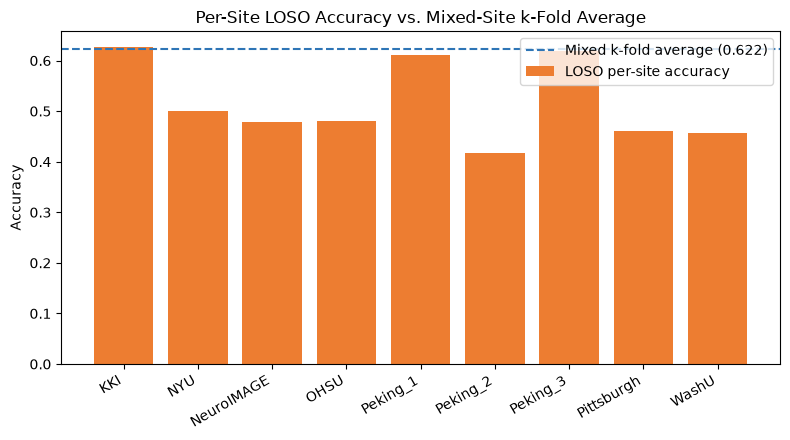

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
sites = loso_results["site"]
ax.bar(sites, loso_results["accuracy"], color="#ED7D31", label="LOSO per-site accuracy")
ax.axhline(mixed_results["accuracy"].mean(), color="#2E75B6", linestyle="--",
           label=f"Mixed k-fold average ({mixed_results['accuracy'].mean():.3f})")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Site LOSO Accuracy vs. Mixed-Site k-Fold Average")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
